# Machine Learning Lab 5 — K-Nearest Neighbours

**Name:** Hanshal Bobate  
**Section:** B  
**Roll No.:** 40  
**Batch:** B3

## Aim
To explore the diabetes dataset through exploratory data analysis and examine feature patterns relevant to a K-Nearest Neighbours (KNN) classification experiment.

### Workflow
1. Import the libraries required for data handling and visualization.
2. Load the diabetes dataset from `diabetes.csv`.
3. Inspect sample records, dataset dimensions, column data types, and descriptive statistics.
4. Check for missing values and duplicate records.
5. Perform univariate analysis of selected features using histograms and KDE plots.
6. Explore relationships between features and the diabetes outcome using scatter plots and boxplots.
7. Examine correlations among numerical features using a correlation heatmap.

**Note:** The cells in this notebook cover dataset inspection and EDA; the existing notebook content is retained as provided.


## 1. Import Required Libraries

Import Pandas and NumPy for working with tabular and numerical data, and Matplotlib and Seaborn for creating visualizations used during exploratory data analysis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

Read `diabetes.csv` into a Pandas DataFrame named `df`. Displaying the DataFrame gives an initial view of the dataset and helps verify that it loaded successfully.

In [ ]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## 3. Preview the First Five Records

Use `head()` to inspect the first five rows. This helps identify the columns, value formats, and general structure of individual records.

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. Preview the Last Five Records

Use `tail()` to inspect the final five rows. This provides a quick check of the end of the dataset and whether records appear to have loaded as expected.

In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


## 5. Inspect Dataset Structure

`info()` reports the number of rows, column names, non-null counts, data types, and memory usage. Use it to identify data-type issues and columns with missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 6. Review Descriptive Statistics

`describe()` summarizes numerical columns using count, mean, standard deviation, minimum, quartiles, and maximum. These statistics help reveal scale differences and potentially unusual values.

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 7. Count Missing Values

`isnull().sum()` counts missing entries in each column. This identifies where data may be incomplete before analysis or model training.

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 8. Check Duplicate Records

`duplicated().sum()` counts rows that are exact duplicates of earlier rows. This helps assess whether repeated records may affect the analysis.

In [ ]:
df.duplicated().sum()

np.int64(0)

## 9. Univariate Analysis: Glucose Distribution

A histogram displays the distribution of glucose measurements, while KDE overlays a smoothed estimate of the distribution. This helps reveal concentration, spread, skewness, and possible unusual values.

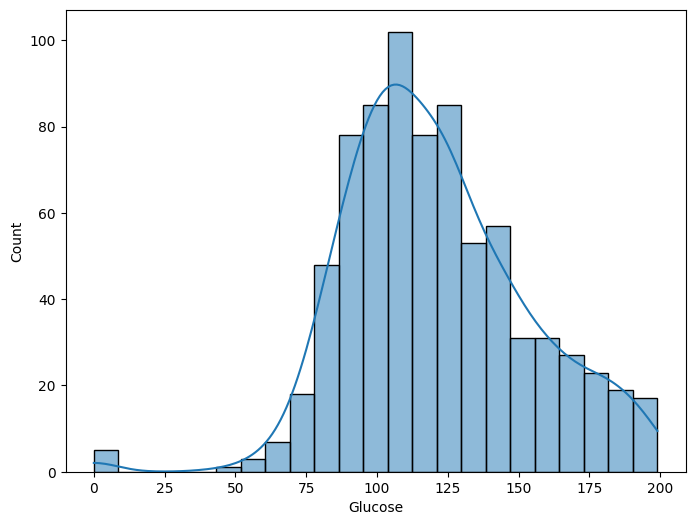

In [ ]:
#Univariate Analysis
plt.figure(figsize=(8,6))
sns.histplot(x=df["Glucose"],kde=True)
plt.show()

## 10. Univariate Analysis: Blood Pressure Distribution

Plot a histogram with a KDE curve for blood-pressure measurements to inspect their distribution, spread, and possible skewness or unusual values.

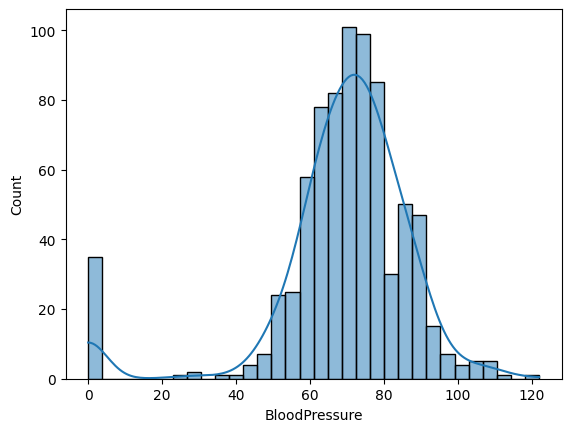

In [ ]:
sns.histplot(x=df["BloodPressure"],kde=True)
plt.show()

## 11. Bivariate Analysis: Glucose vs BMI

A scatter plot compares glucose and BMI for individual records. Look for possible trends, clusters, or unusual observations; association alone does not establish causation.

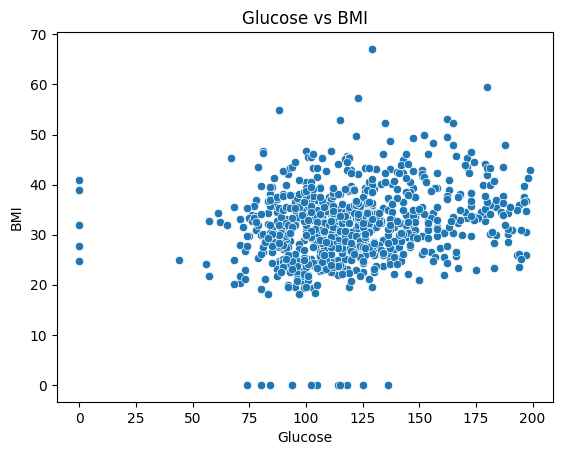

In [ ]:
#Bivariate Analysis
sns.scatterplot(data=df, x="Glucose", y="BMI")
plt.title("Glucose vs BMI")
plt.show()

## 12. Compare Glucose by Outcome

A boxplot compares glucose distributions across the two outcome groups. The median, interquartile range, whiskers, and plotted outliers help show how glucose values differ between groups.

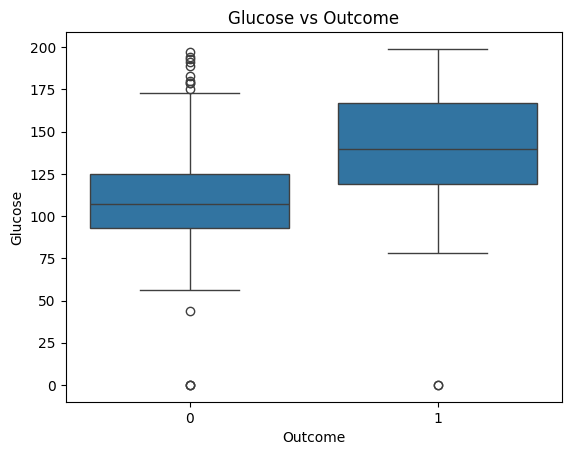

In [ ]:
sns.boxplot(data=df, x="Outcome", y="Glucose")
plt.title("Glucose vs Outcome")
plt.show()

## 13. Multivariate Analysis: Correlation Matrix

Calculate pairwise correlations between numerical columns and display them as a heatmap. Correlations summarize linear relationships; they do not imply causation.

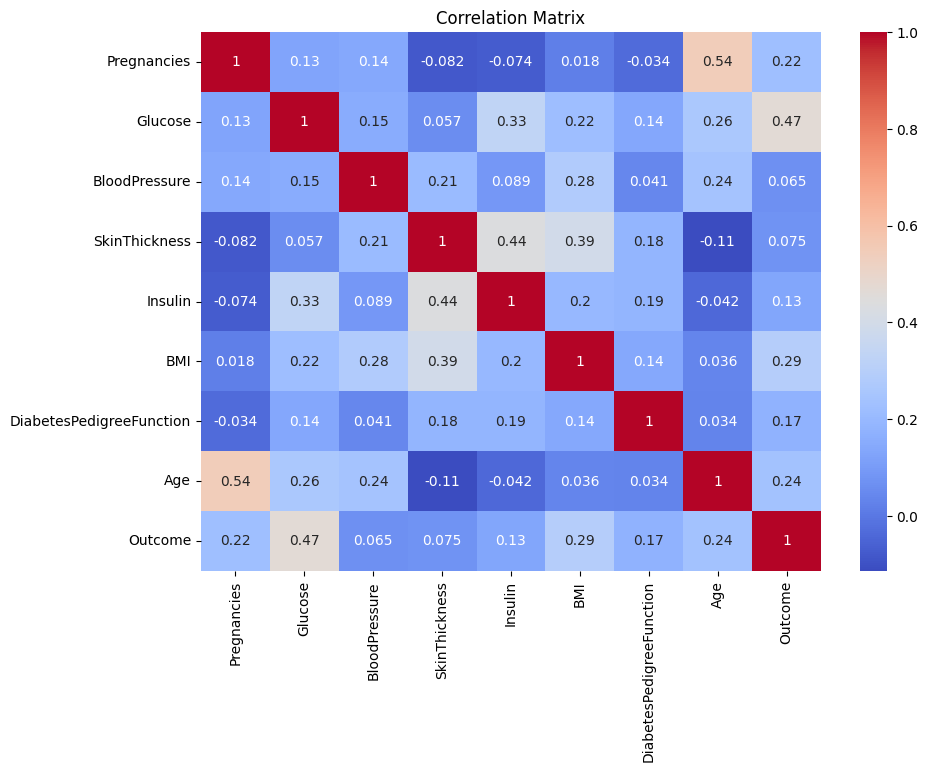

In [ ]:
correlation=df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 14. Dataset Dimensions

The `shape` attribute reports the number of rows and columns. It provides a quick overview of the dataset's size.

In [ ]:
df.shape

## 15. Inspect Column Names

Display the column names to identify the available measurements and the target variable. In this dataset, `Outcome` represents the diabetes outcome label.

In [ ]:
df.columns

## 16. Visualize Missing Values

This heatmap shows the locations of missing values across rows and columns. Bright cells indicate missing entries in the selected color map; if the dataset is large, the plot may be dense.

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values in Diabetes Dataset")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.show()

## 17. Univariate Analysis: Outcome Distribution

A count plot shows how many records belong to each outcome class. Checking class balance is useful because a strongly imbalanced target can affect how model performance should be interpreted.

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Outcome")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Records")
plt.show()

## 18. Outlier Visualization: Glucose

A boxplot summarizes the glucose distribution and highlights observations beyond the whiskers. Such observations should be investigated rather than automatically removed, since they may be valid measurements.

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Glucose")
plt.title("Glucose Boxplot")
plt.show()

## 19. Outlier Visualization: BMI

Use a boxplot to inspect the spread of BMI values and identify potential outliers. The plot is descriptive and does not by itself establish that any value is erroneous.

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="BMI")
plt.title("BMI Boxplot")
plt.show()

## 20. Bivariate Analysis: Features by Outcome

Compare glucose and BMI values across outcome groups using boxplots. This helps inspect whether the distributions differ between records with outcome 0 and outcome 1.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Outcome", y="Glucose", ax=axes[0])
axes[0].set_title("Glucose by Outcome")
sns.boxplot(data=df, x="Outcome", y="BMI", ax=axes[1])
axes[1].set_title("BMI by Outcome")
plt.tight_layout()
plt.show()